# Week 3 Breakout Slides: Data Visualization (Part 2)

In Part 1 we built statistical tools from scratch using NumPy and Matplotlib. In Part 2 we work with **real survey data** and lean on **pandas** — a library built directly on top of NumPy and Matplotlib. Because of that inheritance, a single pandas method call often replaces an entire workflow you would have written by hand.

## Import Libraries

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## Load and Inspect the Data

pandas reads the CSV into a **DataFrame** — a table where every column is a `Series` that inherits NumPy's full statistical engine. All the functions you used in Part 1 (`mean`, `std`, `median`, etc.) are available directly on any DataFrame or Series.

In [2]:
path_to_file = Path('your/path')

In [3]:
df_survey = pd.read_csv(path_to_file / 'survey_results.csv')

### Quick Look: `.describe()`

`.describe()` is a one-liner that runs NumPy's `count`, `mean`, `std`, `min`, and all four percentiles on **every numeric column at once**. In Part 1 you would have called `np.mean()`, `np.std()`, and `np.percentile()` separately for each array.

In [4]:
df_survey.describe()

,Computer Programming in Python,Hardware-computer interfacing,Data Science,Navigating resources
count,26.000000,26.000000,26.000000,26.000000
mean,2.230769,1.923077,2.500000,2.653846
std,1.394495,1.324329,1.421267,1.294366
min,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,2.000000,2.000000
50%,2.000000,1.500000,2.500000,2.500000
75%,3.000000,3.000000,4.000000,3.000000
max,5.000000,5.000000,5.000000,5.000000


### Built-in Box Plot

pandas wraps Matplotlib's boxplot so you can call `.plot.box()` directly on the DataFrame. No loops, no manual calls per column — one line produces a comparison across all four skill areas.

<Axes: >

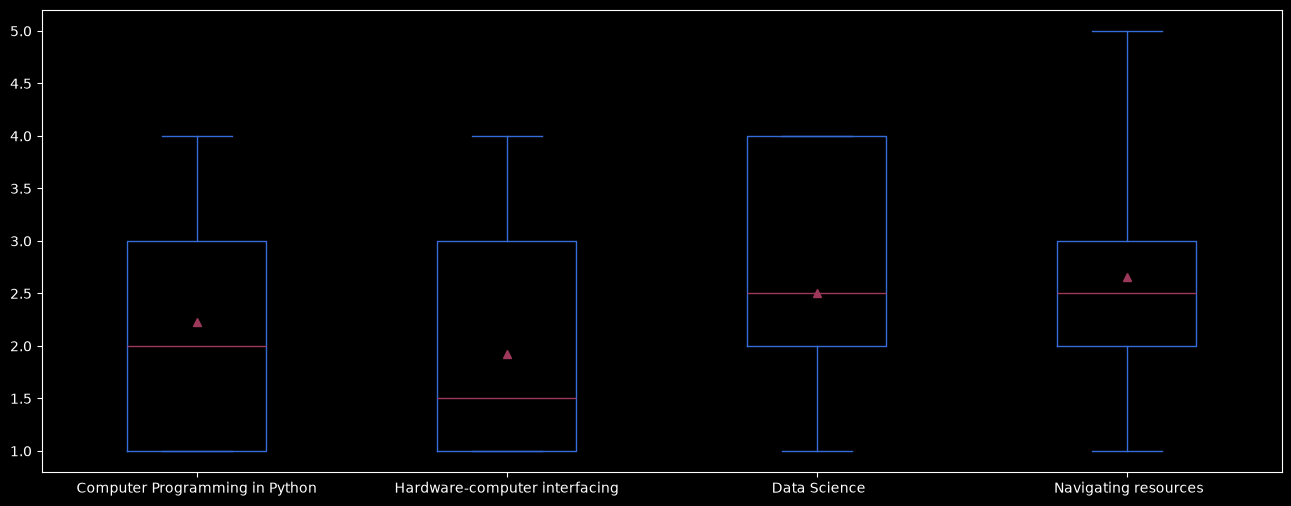

In [5]:
df_survey.plot.box(showmeans=True, figsize=(16, 6), whis=[10, 90], showfliers=False)

### Adding Matplotlib Control

For more control, pass an `ax` object from `plt.subplots()` into the pandas plot call. All standard Matplotlib options still apply — you get the convenience of the pandas API and the full power of Matplotlib.

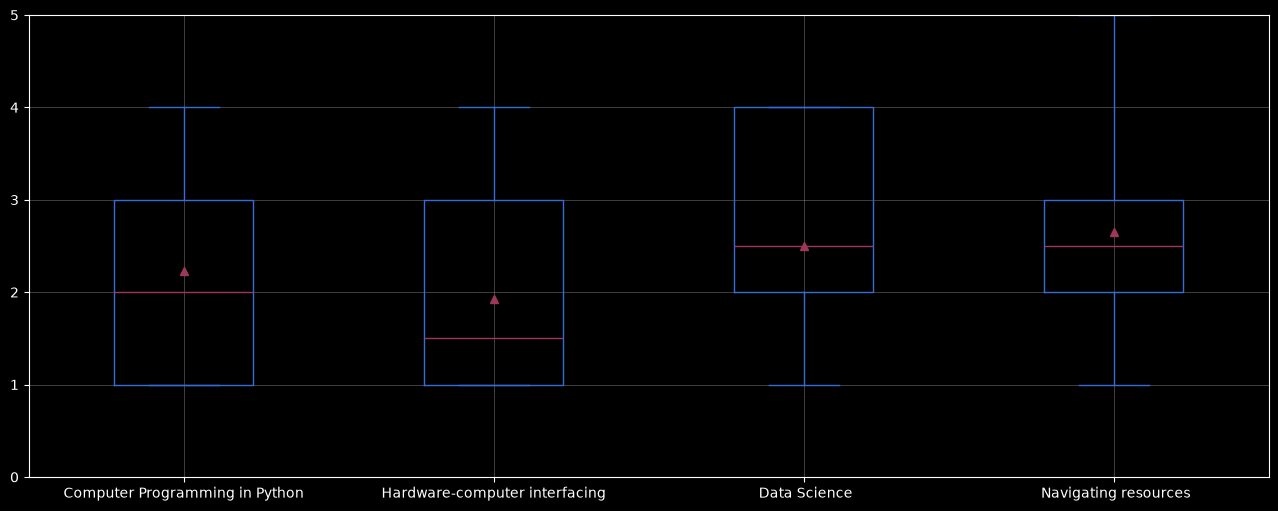

In [6]:
# if you want to add more customization

fig, ax = plt.subplots(figsize=(16, 6))
df_survey.plot.box(showmeans=True, whis=[10, 90], showfliers=False, 
                   ax=ax)

ax.set_ylim([0, 5])
ax.grid()

### Full Matplotlib Customization

When pandas' built-in styling isn't enough, drop down to the raw `ax.boxplot()` call. You still benefit from pandas for data loading and wrangling — just hand the DataFrame values to Matplotlib directly.

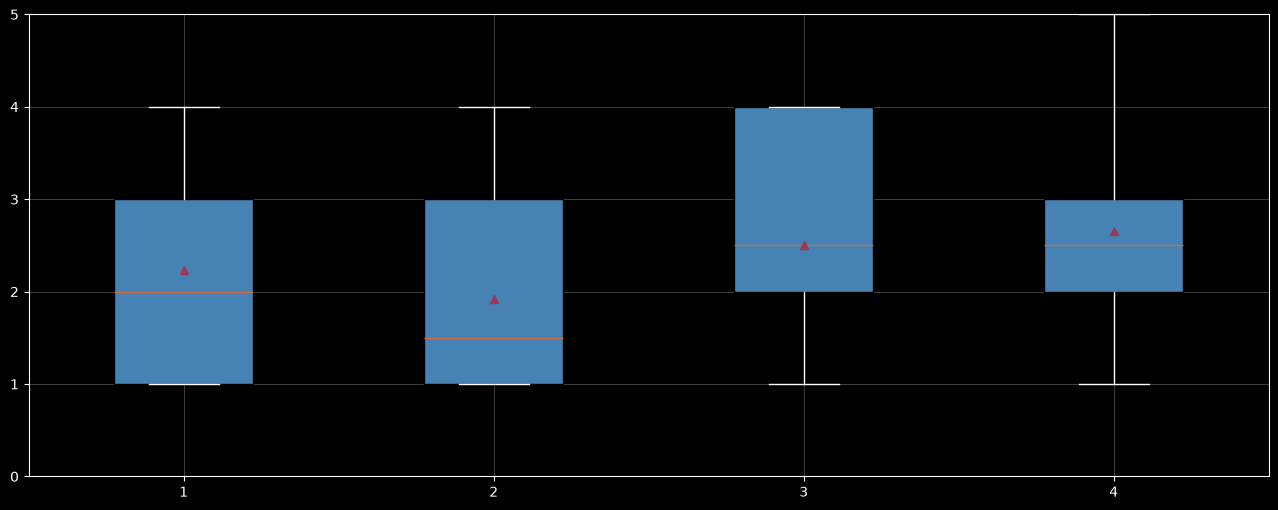

In [7]:
# if you want to add more customization

fig, ax = plt.subplots(figsize=(16, 6))
ax.boxplot(df_survey, showmeans=True, whis=[10, 90], showfliers=False,
           patch_artist=True,  # required for facecolor to apply
           boxprops=dict(facecolor='steelblue', color='k'))

ax.set_ylim([0, 5])
ax.grid()

## Distributions

`.describe()` gives summary statistics, but looking at the actual shape of the data tells a richer story. pandas `.hist()` plots all columns in a single call — no loop needed.

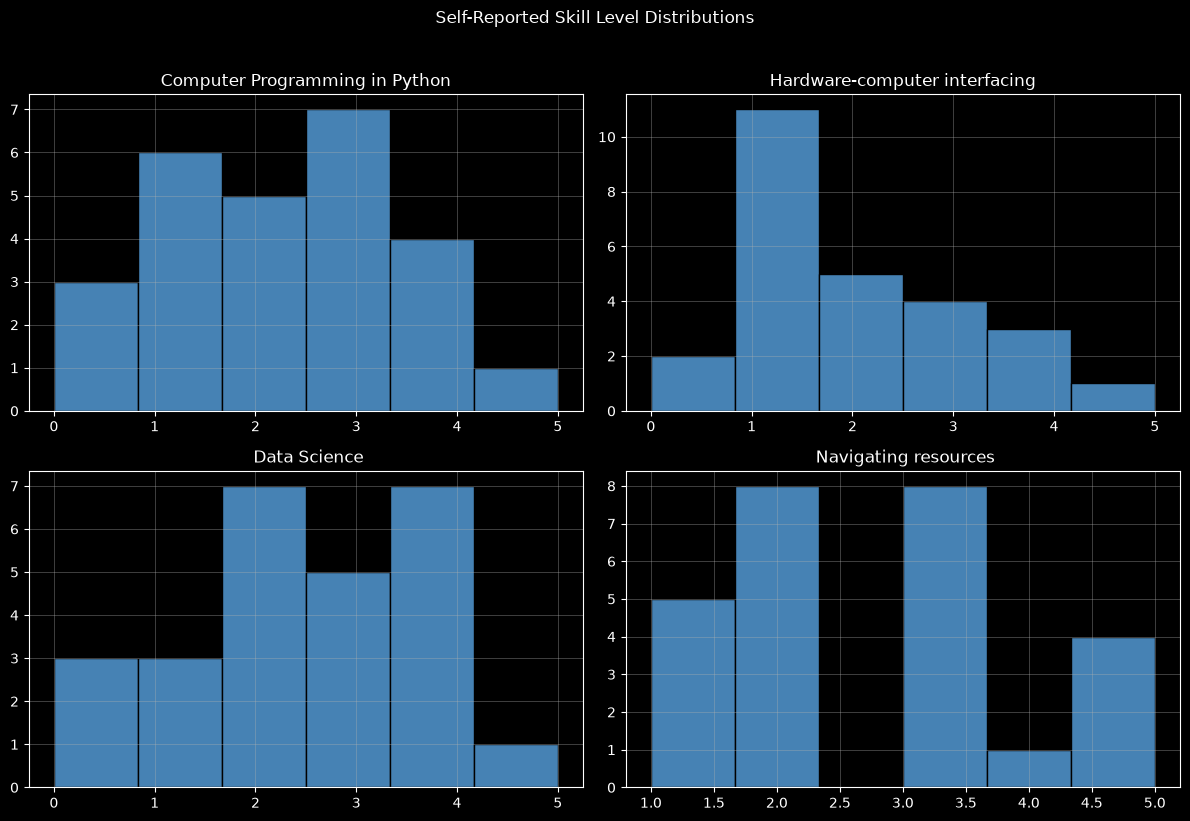

In [8]:
df_survey.hist(bins=6,          # 6 bins covers the 0–5 scale neatly
               figsize=(12, 8),
               layout=(2, 2),   # arrange subplots in a 2×2 grid
               edgecolor='k',
               color='steelblue')

plt.suptitle('Self-Reported Skill Level Distributions', y=1.02)
plt.tight_layout()

### Rating Frequency

For ordinal data like 0–5 ratings, `.value_counts()` tallies each response. Chain `.sort_index()` to keep the x-axis ordered, then call `.plot.bar()` directly on the resulting Series — no intermediate variables needed.

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

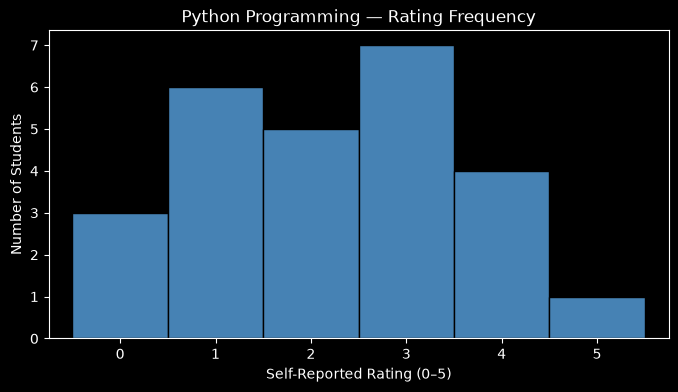

In [19]:
(df_survey['Computer Programming in Python']
    .value_counts()
    .sort_index()
    .plot.bar(color='steelblue', edgecolor='k', width=1, figsize=(8, 4)))

plt.xlabel('Self-Reported Rating (0–5)')
plt.ylabel('Number of Students')
plt.title('Python Programming — Rating Frequency')
plt.xticks(rotation=0)

## Summary Statistics

pandas exposes NumPy's full statistical toolkit directly on the DataFrame. Call `.mean()`, `.median()`, or `.std()` on the whole table and get a result for every column simultaneously — no iteration, no index management.

In [10]:
print("Means:\n",   df_survey.mean(numeric_only=True).round(2), "\n")
print("Medians:\n", df_survey.median(numeric_only=True).round(2), "\n")
print("Std Dev:\n", df_survey.std(numeric_only=True).round(2))

Means:
 Computer Programming in Python    2.23
Hardware-computer interfacing     1.92
 Data Science                     2.50
 Navigating resources             2.65
dtype: float64 

Medians:
 Computer Programming in Python    2.0
Hardware-computer interfacing     1.5
 Data Science                     2.5
 Navigating resources             2.5
dtype: float64 

Std Dev:
 Computer Programming in Python    1.39
Hardware-computer interfacing     1.32
 Data Science                     1.42
 Navigating resources             1.29
dtype: float64


### Ranked Comparison

Chaining pandas operations produces a publication-ready figure in a single expression: compute the column means, sort them, then call `.plot.barh()` directly on the resulting Series.

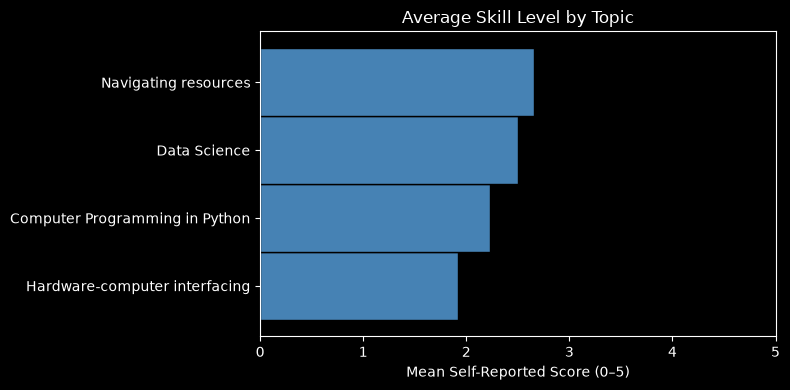

In [21]:
(df_survey.mean(numeric_only=True)
          .sort_values()
          .plot.barh(color='steelblue', width=1, edgecolor='k', figsize=(8, 4)))

plt.xlabel('Mean Self-Reported Score (0–5)')
plt.title('Average Skill Level by Topic')
plt.xlim([0, 5])
plt.tight_layout()

## Hypothesis Testing

The boxplots and ranked comparison tell us the means look different — but are those differences real or just noise from a sample of 26 students? Statistical tests give us a principled answer. We use `scipy.stats`, which integrates seamlessly with pandas: just pass a DataFrame column (a Series) directly to any test function.

In [12]:
from scipy import stats

### Parametric Tests

Parametric tests assume the underlying data is roughly normally distributed. Here we apply them to the survey ratings as a first pass — we'll revisit whether that assumption holds in the non-parametric section below.

#### One-Sample t-test: Is each topic rated above or below the midpoint?

The scale runs 0–5, so 2.5 is the neutral midpoint. A one-sample t-test tells us whether each topic's mean is significantly different from that reference value — pandas column access hands each Series directly to `ttest_1samp`.

In [13]:
midpoint = 2.5  # neutral middle of the 0–5 scale

print(f"{'Topic':<35} {'Mean':>6} {'t':>8} {'p':>10}  Decision")
print("-" * 75)
for col in df_survey.columns:
    t, p = stats.ttest_1samp(df_survey[col], popmean=midpoint)
    if p < 0.05:
        direction = "below midpoint" if t < 0 else "above midpoint"
    else:
        direction = "no difference"
    print(f"{col:<35} {df_survey[col].mean():>6.2f} {t:>8.3f} {p:>10.4f}  {direction}")

Topic                                 Mean        t          p  Decision
---------------------------------------------------------------------------
Computer Programming in Python        2.23   -0.984     0.3343  no difference
Hardware-computer interfacing         1.92   -2.221     0.0356  below midpoint
 Data Science                         2.50    0.000     1.0000  no difference
 Navigating resources                 2.65    0.606     0.5499  no difference


#### Paired t-test: Do two topics differ within students?

Each row is one student who rated **all four** topics, so the data is paired — the same person's scores go into both groups. A paired t-test removes between-student variability, making it more sensitive than an independent-samples test would be here.

In [14]:
python_col   = 'Computer Programming in Python'
hardware_col = 'Hardware-computer interfacing'

t_stat, p_value = stats.ttest_rel(df_survey[python_col], df_survey[hardware_col])
print(f"Paired t-test: Python vs. Hardware")
print(f"  Mean Python:   {df_survey[python_col].mean():.2f}")
print(f"  Mean Hardware: {df_survey[hardware_col].mean():.2f}")
print(f"  t = {t_stat:.4f},  p = {p_value:.4f}")
print(f"  → {'Significant difference' if p_value < 0.05 else 'No significant difference'} (α = 0.05)")

Paired t-test: Python vs. Hardware
  Mean Python:   2.23
  Mean Hardware: 1.92
  t = 0.9841,  p = 0.3345
  → No significant difference (α = 0.05)


### Non-Parametric Tests

Our ratings are **ordinal** (0–5 integers) from only **26 students** — the normality assumption required by t-tests is questionable. Non-parametric tests make no distributional assumptions: they rank the data instead of computing on raw values, making them more appropriate for this dataset.

#### Wilcoxon Signed-Rank Test

The non-parametric equivalent of the paired t-test. It ranks the absolute differences between each student's two ratings and tests whether those differences are symmetric around zero — no normality required.

In [15]:
w_stat, p_value_w = stats.wilcoxon(df_survey[python_col], df_survey[hardware_col])
print(f"Wilcoxon Signed-Rank: Python vs. Hardware")
print(f"  W = {w_stat:.0f},  p = {p_value_w:.4f}")
print(f"  → {'Significant difference' if p_value_w < 0.05 else 'No significant difference'} (α = 0.05)")

Wilcoxon Signed-Rank: Python vs. Hardware
  W = 50,  p = 0.3590
  → No significant difference (α = 0.05)


#### Kruskal-Wallis Test: All Four Topics at Once

The non-parametric equivalent of a one-way ANOVA — tests whether at least one topic's distribution differs from the others. A significant result tells you *something* differs; follow-up pairwise Wilcoxon tests identify which pairs.

In [16]:
h_stat, p_value_kw = stats.kruskal(*[df_survey[c] for c in df_survey.columns])
print(f"Kruskal-Wallis: all four topics")
print(f"  H = {h_stat:.4f},  p = {p_value_kw:.4f}")
print(f"  → {'At least one topic differs significantly' if p_value_kw < 0.05 else 'No significant difference between topics'} (α = 0.05)")

Kruskal-Wallis: all four topics
  H = 4.4857,  p = 0.2136
  → No significant difference between topics (α = 0.05)


### Parametric vs. Non-Parametric: Side-by-Side

A key skill is knowing which test to use and checking whether the two approaches agree. When they disagree, the non-parametric result is usually more trustworthy for small ordinal samples.

In [17]:
alpha = 0.05

paired_t_p  = stats.ttest_rel(df_survey[python_col], df_survey[hardware_col]).pvalue
wilcoxon_p  = stats.wilcoxon(df_survey[python_col], df_survey[hardware_col]).pvalue

print(f"{'Test':<30} {'p-value':>12}  Decision")
print("-" * 58)
for label, p in [("Paired t-test", paired_t_p), ("Wilcoxon signed-rank", wilcoxon_p)]:
    print(f"{label:<30} {p:>12.4f}  {'Reject H₀' if p < alpha else 'Fail to reject H₀'}")

Test                                p-value  Decision
----------------------------------------------------------
Paired t-test                        0.3345  Fail to reject H₀
Wilcoxon signed-rank                 0.3590  Fail to reject H₀


## Pairwise Relationships

`pd.plotting.scatter_matrix()` is a pandas built-in that replaces what would otherwise be a double nested loop of `plt.scatter()` calls. Off-diagonal cells show every pairwise scatter plot; diagonal cells show each variable's own distribution.

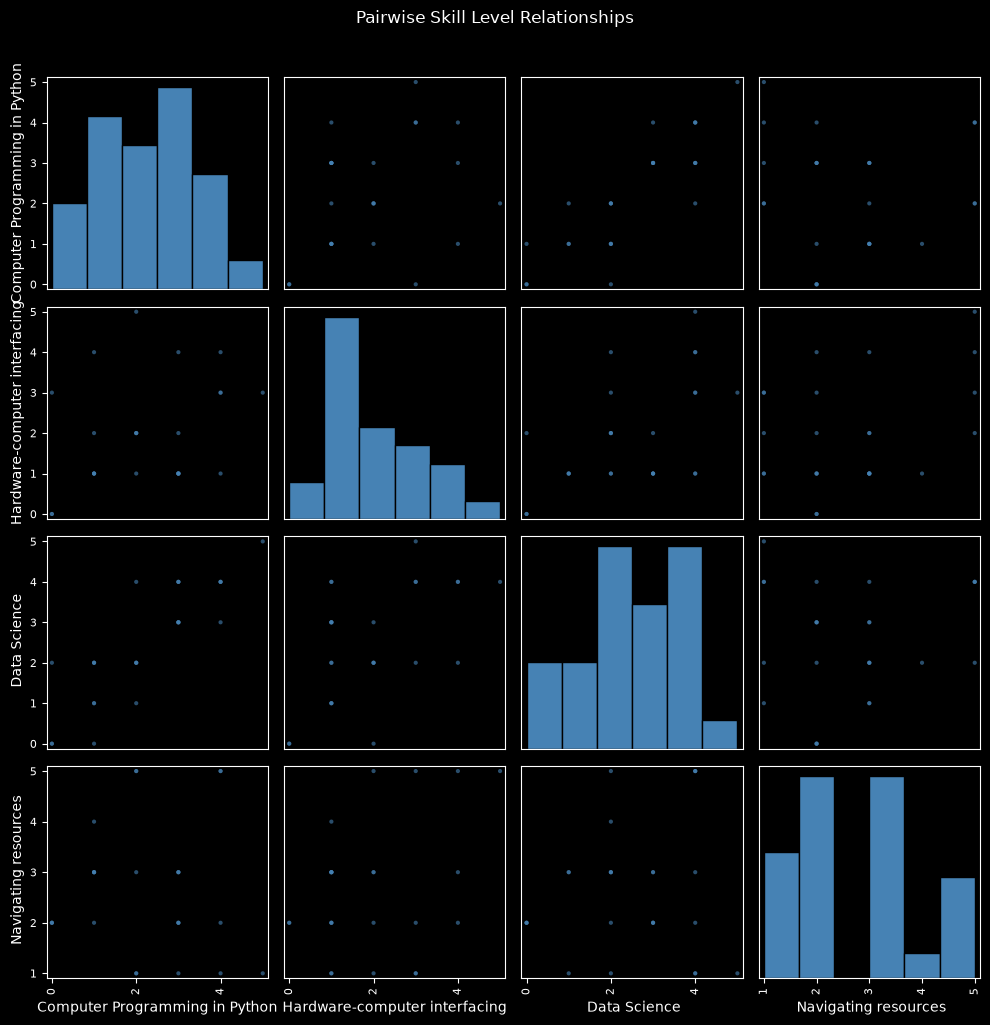

In [18]:
pd.plotting.scatter_matrix(
    df_survey,
    figsize=(10, 10),
    diagonal='hist',   # histogram on the diagonal, scatter elsewhere
    alpha=0.6,
    hist_kwds={'bins': 6, 'edgecolor': 'k', 'color': 'steelblue'},
    color='steelblue'
)

plt.suptitle('Pairwise Skill Level Relationships', y=1.02)
plt.tight_layout()